# <font color='Orange'>Hope everyone who reads this notebook finds it helpful. Do upvote it. Thank You 🙏😃

# <font color ='torcous'>EMNIST Letter Dataset with 96.7% accuracy 

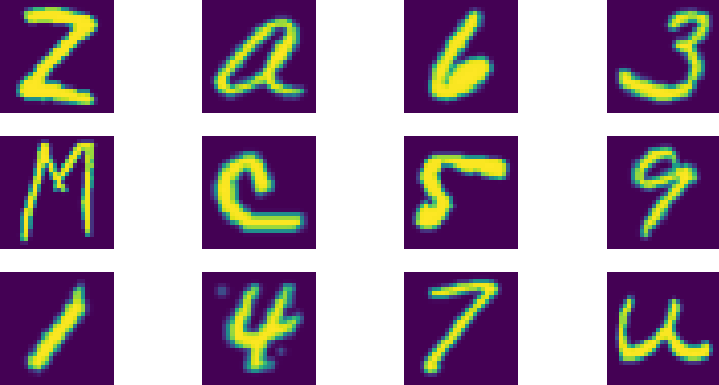

## <font color='#00B2FF'> The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset .


Code from https://www.kaggle.com/code/achintyatripathi/emnist-letter-dataset-97-9-acc-val-acc-91-78

## Here we are specifically using EMNIST letter dataset. So Let's get started

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
ROOT_DIR = '../CNN_training/emnist/'
for dirname, _, filenames in os.walk(ROOT_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

../CNN_training/emnist/emnist-mnist-test.csv
../CNN_training/emnist/emnist-mnist-train.csv
../CNN_training/emnist/emnist-mnist-mapping.txt
../CNN_training/emnist/emnist-bymerge-train.csv
../CNN_training/emnist/emnist-digits-test.csv
../CNN_training/emnist/emnist-letters-mapping.txt
../CNN_training/emnist/emnist-byclass-mapping.txt
../CNN_training/emnist/emnist-letters-test.csv
../CNN_training/emnist/emnist-bymerge-mapping.txt
../CNN_training/emnist/emnist-digits-train.csv
../CNN_training/emnist/emnist-balanced-mapping.txt
../CNN_training/emnist/emnist-letters-train.csv
../CNN_training/emnist/emnist-byclass-test.csv
../CNN_training/emnist/emnist-balanced-train.csv
../CNN_training/emnist/emnist-bymerge-test.csv
../CNN_training/emnist/emnist-digits-mapping.txt
../CNN_training/emnist/emnist-balanced-test.csv
../CNN_training/emnist/emnist-byclass-train.csv
../CNN_training/emnist/emnist_source_files/emnist-bymerge-test-images-idx3-ubyte
../CNN_training/emnist/emnist_source_files/emnist-lette

In [2]:
#/kaggle/input/emnist/emnist-letters-mapping.txt
testing_letter = pd.read_csv(ROOT_DIR + 'emnist-letters-test.csv')
training_letter = pd.read_csv(ROOT_DIR + 'emnist-letters-train.csv')

In [3]:
print(training_letter.shape)
print(testing_letter.shape)

(88799, 785)
(14799, 785)


In [4]:
#training_letters
y1 = np.array(training_letter.iloc[:,0].values)
x1 = np.array(training_letter.iloc[:,1:].values)
#testing_labels
y2 = np.array(testing_letter.iloc[:,0].values)
x2 = np.array(testing_letter.iloc[:,1:].values)
print(y1.shape)
print(x1.shape)

(88799,)
(88799, 784)


## Let's see what type of images we have got. 

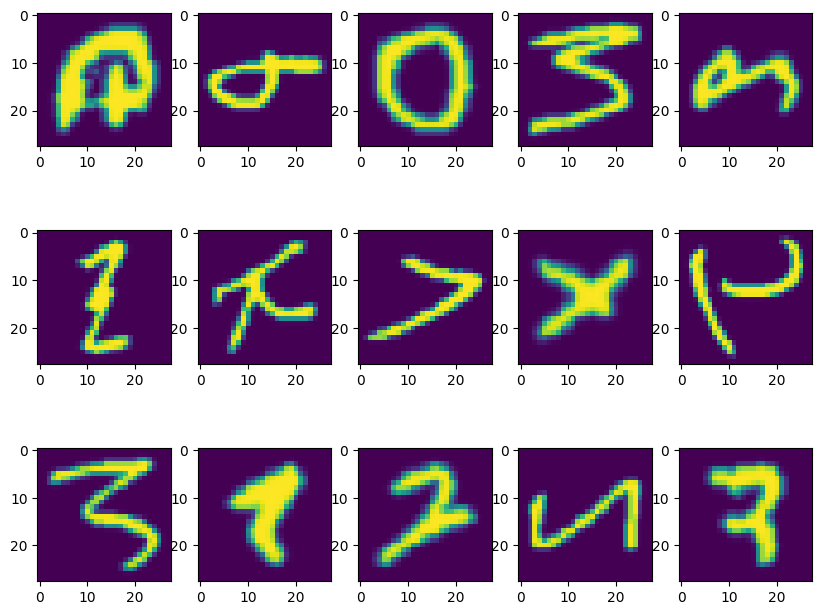

In [5]:
import matplotlib.pyplot as plt 
fig,axes = plt.subplots(3,5,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    ax.imshow(x1[i].reshape([28,28]))


In [6]:
import tensorflow as tf

2026-02-15 19:47:35.615896: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 19:47:35.650138: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 19:47:36.362395: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Preprocesssing

# 1. Normalisation and reshaping of data

### Before feeding in the data to the model we will normalise and reshape the data given to us. This will decrease the complexity of the models and make the model work efficiently as less complex numbers will be there to process.

In [7]:
# Normalise and reshape data
train_images = x1 / 255.0
test_images = x2 / 255.0

train_images_number = train_images.shape[0]
train_images_height = 28
train_images_width = 28
train_images_size = train_images_height*train_images_width


# train_images = train_images.reshape(train_images_number, train_images_height, train_images_width, 1)

# correct image orientation
# Reshape to (n_samples, 28, 28) first
train_images = train_images.reshape(train_images_number, train_images_height, train_images_width)

# Apply transpose and flip to correct EMNIST orientation
train_images = np.array([np.transpose(img) for img in train_images])

# Now add the channel dimension
train_images = train_images.reshape(train_images_number, train_images_height, train_images_width, 1)

test_images_number = test_images.shape[0]
test_images_height = 28
test_images_width = 28
test_images_size = test_images_height*test_images_width

# test_images = test_images.transpose()
# test_images = test_images.reshape(test_images_number, test_images_height, test_images_width, 1)

test_images = test_images.reshape(test_images_number, test_images_height, test_images_width)
test_images = np.array([np.flipud(np.transpose(img)) for img in test_images])
test_images = test_images.reshape(test_images_number, test_images_height, test_images_width, 1)

### correct image orientation to upright

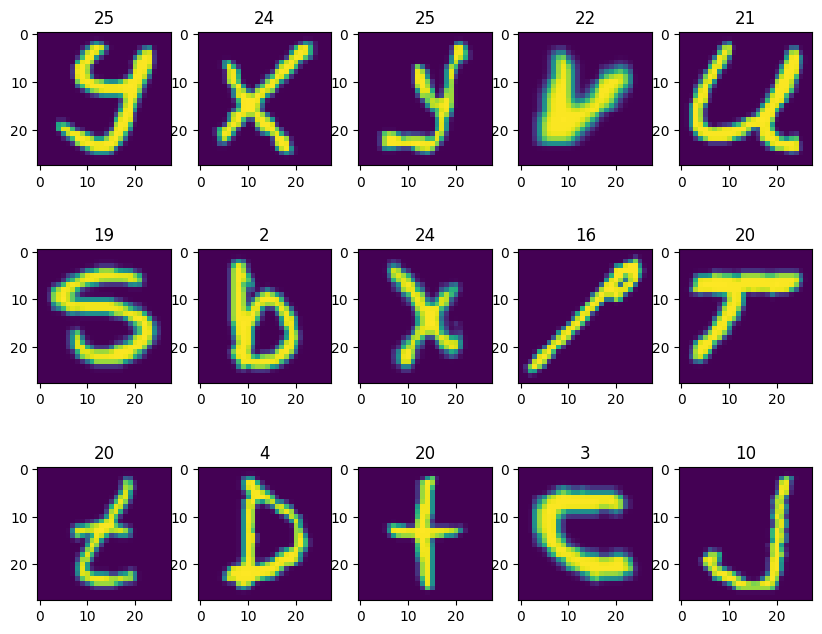

In [8]:
fig,axes = plt.subplots(3,5,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    custom_idx = i*500+i+20
    ax.set_title(f"{y1[custom_idx]}")
    # ax.imshow(test_images[custom_idx].reshape(28,28))
    ax.imshow(train_images[custom_idx])

In [25]:
# Transform labels
number_of_classes = np.unique(y1)

print(number_of_classes1)
# y1 = tf.keras.utils.to_categorical(y1, number_of_classes)
# y2 = tf.keras.utils.to_categorical(y2, number_of_classes)

AttributeError: 'numpy.ndarray' object has no attribute 'len'

# Lets create a CNN for the classification of these random images.

In [10]:
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from tensorflow.keras.models import Model
#from tensorflow.keras.layers import Dense,Dropout,MaxPooling2D,Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau,ModelCheckpoint

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
train_x,test_x,train_y,test_y = train_test_split(train_images,y1,test_size=0.2,random_state = 42)

In [13]:
model = tf.keras.Sequential([ 
    tf.keras.layers.Conv2D(32,3,input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(number_of_classes,activation='softmax')
])

/home/sai/Documents/School/AY2025-2026/T2/THSCE03/THES2/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sai/Documents/School/AY2025-2026/T2/THSCE03/THES2/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1771156058.670075  135449 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1184 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [14]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

## Adding Callback API's to save best weights and change lr

In [15]:
 
MCP = ModelCheckpoint('hw.keras',verbose=1,save_best_only=True,monitor='val_accuracy',mode='max')
ES = EarlyStopping(monitor='val_accuracy',min_delta=0,verbose=0,restore_best_weights = True,patience=3,mode='max')
RLP = ReduceLROnPlateau(monitor='val_loss',patience=3,factor=0.2,min_lr=0.0001)

In [16]:
history = model.fit(train_x,train_y,epochs=10,validation_data=(test_x,test_y),callbacks=[MCP,ES,RLP])

Epoch 1/10


2026-02-15 19:47:39.914997: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f9a34007870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-15 19:47:39.915014: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-02-15 19:47:39.933692: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-15 19:47:40.010020: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-15 19:47:40.033130: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-15 19:47:40.

 135/2220 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3848 - loss: 2.2160

I0000 00:00:1771156063.227192  135918 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2193/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7310 - loss: 0.8940

2026-02-15 19:47:46.515611: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_320', 8 bytes spill stores, 8 bytes spill loads

2026-02-15 19:47:46.569151: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_320', 4 bytes spill stores, 4 bytes spill loads

2026-02-15 19:47:46.734143: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_320', 8 bytes spill stores, 8 bytes spill loads



2220/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7321 - loss: 0.8900
Epoch 1: val_accuracy improved from None to 0.88666, saving model to hw.keras

Epoch 1: finished saving model to hw.keras
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8241 - loss: 0.5646 - val_accuracy: 0.8867 - val_loss: 0.3455 - learning_rate: 0.0010
Epoch 2/10
2184/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9090 - loss: 0.2746
Epoch 2: val_accuracy improved from 0.88666 to 0.89668, saving model to hw.keras

Epoch 2: finished saving model to hw.keras
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9090 - loss: 0.2758 - val_accuracy: 0.8967 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 3/10
2196/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9311 - loss: 0.2007
Epoch 3: val_accuracy improved from 0.89668 to 0.89904, saving model to hw.keras

Epoch 3: finished saving model to hw.keras
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9295 - loss: 0.2077 - val_accur

## Let's plot Accuracy vs Val_Accuracy to further evaluation..

In [17]:
import seaborn as sns

Text(0, 0.5, 'Accuray')

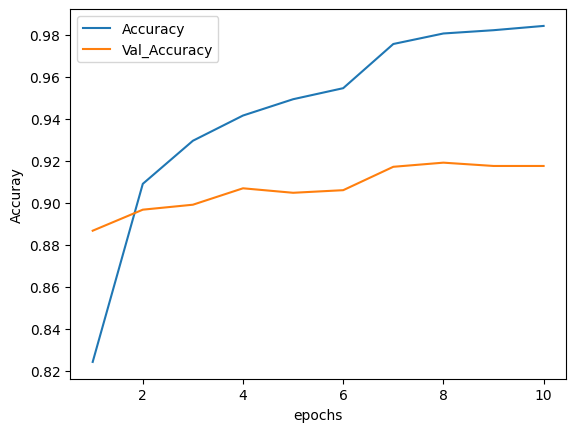

In [18]:
q = len(history.history['accuracy'])

plt.figsize=(10,10)
sns.lineplot(x = range(1,1+q),y = history.history['accuracy'], label='Accuracy')
sns.lineplot(x = range(1,1+q),y = history.history['val_accuracy'], label='Val_Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuray')

## Changing the test_split size to 0.15 to see if validation score increases or not

In [19]:
train_x2,test_x2,train_y2,test_y2 = train_test_split(train_images,y1,test_size=0.15,random_state = 42)

In [20]:
history1 = model.fit(train_x2,train_y2,epochs=10,validation_data=(test_x2,test_y2))

Epoch 1/10
2349/2359 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9798 - loss: 0.0609

2026-02-15 19:48:31.497838: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_320', 8 bytes spill stores, 8 bytes spill loads

2026-02-15 19:48:31.617774: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_320', 4 bytes spill stores, 4 bytes spill loads

2026-02-15 19:48:31.702885: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_320', 8 bytes spill stores, 8 bytes spill loads



2359/2359 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9793 - loss: 0.0631 - val_accuracy: 0.9216 - val_loss: 0.4041
Epoch 2/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9808 - loss: 0.0545 - val_accuracy: 0.9191 - val_loss: 0.4250
Epoch 3/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9823 - loss: 0.0486 - val_accuracy: 0.9190 - val_loss: 0.4313
Epoch 4/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9830 - loss: 0.0449 - val_accuracy: 0.9179 - val_loss: 0.4317
Epoch 5/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9833 - loss: 0.0421 - val_accuracy: 0.9189 - val_loss: 0.4390
Epoch 6/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9846 - loss: 0.0399 - val_accuracy: 0.9153 - val_loss: 0.4847
Epoch 7/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9847 - loss: 0.0384 - val_accuracy: 0.9165 - val_loss: 0.5014
Epoch 8/10
2359/2359 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9852 - loss: 0.0374 - val_accurac

Text(0, 0.5, 'Accuray')

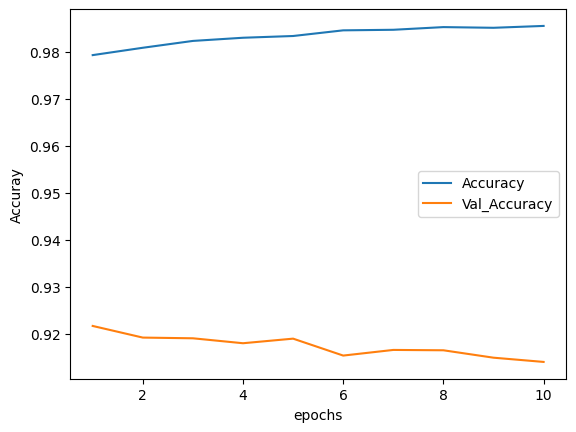

In [21]:
q = len(history1.history['accuracy'])

plt.figsize=(10,10)
sns.lineplot(x = range(1,1+q),y = history1.history['accuracy'], label='Accuracy')
sns.lineplot(x = range(1,1+q),y = history1.history['val_accuracy'], label='Val_Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuray')

# As the validation score score went down we won't be changing the test_split size. 
# Thus the above model is better than the latter one.

## Hope everyone who reads this notebook finds it helpful. 
## Do upvote it. Thank You🙏😃